# CDR tracer vs. truth: efficiency error

The **CDR tracer** uses prescribed *control* sensitivities (β_c, η_c); the **truth** uses the
*perturbed* sensitivities (β_t > β_c, η_t < η_c) that the intervention itself creates.

| | CDR tracer | truth | consequence |
|---|---|---|---|
| $\beta$ (buffer factor) | $\beta_c$ (smaller) | $\beta_t > \beta_c$ | faster CDR rate |
| $\eta$ (dDIC/dALK) | $\eta_c$ (larger) | $\eta_t < \eta_c$ | higher CDR plateau |

Both factors push $C_{\text{CDR}}(t) > C_{\text{truth}}(t)$ for every $t$ — until the plateau gap
can reverse that.  The observed crossover therefore cannot come from the β/η linearisation.

---

## Model

One surface box, effective mixing depth $h$, piston velocity $k$, intervention rate $S$ applied
over $0 \le t \le T$.  Relaxation rate

$$a = \frac{k/\beta}{h}$$

For OAE, alkalinity is conservative and DIC relaxes toward it:

$$\frac{dA}{dt} = \frac{S}{h}\;(t\le T),\qquad
  \frac{dD}{dt} = a(\eta A - D),\qquad F = h\,a\,(\eta A - D)$$

**The substitution.** Solve not for $D$ but for the *disequilibrium* $G \equiv \eta A - D$
(proportional to the flux, $F = h\,a\,G$):

$$\frac{dG}{dt} = \eta\frac{dA}{dt} - \frac{dD}{dt} = \eta\frac{dA}{dt} - aG$$

one linear ODE with constant coefficient.  Forcing on ($dA/dt = S/h$, $G(0)=0$) gives
$G = \frac{\eta S}{ah}(1-e^{-at})$; forcing off ($dA/dt=0$) gives pure decay from the phase-1
endpoint.  Multiplying by $ha$:

$$\boxed{\;F(t) = \eta\,S\,\bigl(1 - e^{-a\min(t,T)}\bigr)\,e^{-a\max(t-T,\,0)}\;}$$

Normalising the total intervention to 1 ($S\,T = 1$), the efficiency curve $C(t) = \int_0^t F\,dt'$
has the closed form

$$C(t) = \begin{cases}
  \dfrac{\eta}{T}\!\left(t - \dfrac{1 - e^{-at}}{a}\right) & t \le T \\[10pt]
  C(T) + \dfrac{\eta}{T}\,(1 - e^{-aT})\,\dfrac{1 - e^{-a(t-T)}}{a} & t > T
\end{cases}$$

and plateaus at $C(\infty) = \eta$.

**Flux crossover** $t^*$ — time when $F_\mathrm{CDR}(t^*) = F_\mathrm{truth}(t^*)$.  Since both fluxes
rise from zero during the intervention, the crossing (if any) must occur after forcing stops ($t > T$),
where both decay purely exponentially.  Setting the phase-2 expressions equal and solving:

$$\boxed{\;t^* = T + \frac{1}{a_c - a_t}\ln\!\left(\frac{\eta_c\,(1 - e^{-a_c T})}{\eta_t\,(1 - e^{-a_t T})}\right)\;}$$

$t^*$ exists (is real and $> T$) only when the log argument $> 1$, which requires $\eta_c > \eta_t$.
When $\eta_c \le \eta_t$ the CDR-tracer flux stays below truth for all time and there is no crossover.

**DOR** is the same with $\eta = 1$ — there the deficit is the disequilibrium.

Two versions of everything: the CDR tracer uses $( \beta_c, \eta_c )$, the truth $( \beta_t, \eta_t )$,
giving rates $a_c > a_t$ since $\beta_t > \beta_c$.

---

## Efficiency error

$$\varepsilon_{\text{eff}}(t) \;=\; C_{\text{CDR}}(t) - C_{\text{truth}}(t)$$

**Asymptote** (exact, independent of $\beta$, $h$, $k$, $T$):

$$\varepsilon_{\text{eff}}(\infty) = \eta_{\text{CDR}} - \eta_{\text{truth}}$$

**Start.**  For small $t$, $C \approx \eta\,a\,t\cdot$(const), so the error starts *positive*
whenever $\eta_c a_c > \eta_t a_t$ — delivered by the rate bias $a_c > a_t$.

**Crossing condition.**  Positive start + negative asymptote $\Rightarrow$ exactly one crossing,
which exists *iff* $\eta_{\text{truth}} > \eta_{\text{CDR}}$.  If $\eta_{\text{truth}} \le \eta_{\text{CDR}}$
the error stays positive for all time — no $\beta$, $h$, $k$ or $T$ can rescue it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cdr_tracer_curves as ct
from cdr_tracer_curves import DAY, flux, cumulative, rate

SURF, INK, INK2, MUTED = ct.SURF, ct.INK, ct.INK2, ct.MUTED
GRID, AXIS = ct.GRID, ct.AXIS
CDR, TRUTH, NEG = ct.CDR, ct.TRUTH, ct.NEG
RAMP = ct.RAMP


def style(ax, ylab, title, xlab="days since start of deployment"):
    ax.set_facecolor(SURF)
    ax.grid(True, axis="y", color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS); ax.spines[s].set_linewidth(1)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    ax.set_ylabel(ylab, color=INK2, fontsize=9.5)
    ax.set_xlabel(xlab, color=INK2, fontsize=9.5)
    ax.set_title(title, color=INK, fontsize=11, loc="left", pad=9, fontweight="bold")

In [2]:
# ── Schematic: CDR tracer always over-estimates ───────────────────────────

c = ct.curves(beta_c=15.0, beta_t=24.0, eta_c=0.85, eta_t=0.82,
              h_m=20, years=5, n=10001)
td = c['t_days']
p = c['params']
print(f"beta_ctrl={p['beta_c']:.4g}  beta_pert={p['beta_t']:.4g}  "
      f"eta_ctrl={p['eta_c']:.4g}  eta_pert={p['eta_t']:.4g}  "
      f"h={p['h_m']:.4g} m  k={p['k']:.0e} cm/s  T={p['T_days']:.4g} d")

C_COL = "#1b9e77"   # CDR tracer
T_COL = "#d95f02"   # truth
# stored fluxes are in 10^-3 d^-1; scale to 10^-7 s^-1
FLUX_SCALE = 1e4 / DAY  # = 1e7 / (DAY * 1e3)

def _ax(ax):
    for s in ('top', 'right', 'bottom'): ax.spines[s].set_visible(False)
    ax.spines['left'].set_color(AXIS); ax.spines['left'].set_linewidth(1)
    ax.grid(True, axis='y', color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9, length=0, bottom=False)
    ax.set_xticks([])
    arr = ax.annotate('', xy=(1.0, 0), xytext=(0, 0),
                      xycoords='axes fraction', textcoords='axes fraction',
                      annotation_clip=False,
                      arrowprops=dict(arrowstyle='-|>', color=AXIS,
                                     lw=1.2, mutation_scale=14))
    if arr.arrow_patch is not None:
        arr.arrow_patch.set_clip_on(False)
    ax.annotate('time', xy=(0.5, -0.12), xycoords='axes fraction',
                ha='center', va='top', color=INK2, fontsize=10,
                annotation_clip=False)

def _vline_T(ax):
    ax.axvline(p['T_days'], color=MUTED, lw=1, ls=(0, (4, 3)), zorder=2)
    ax.text(p['T_days'], -0.05, r'$T$', transform=ax.get_xaxis_transform(),
            ha='center', va='top', color="k", fontsize=9, clip_on=False)

def _vline_tstar(ax):
    if c['t_star_flux'] is not None:
        ax.axvline(c['t_star_flux'], color=MUTED, lw=1, ls=(0, (4, 3)), zorder=2)
        ax.text(c['t_star_flux'], -0.05, r'$t^*$', transform=ax.get_xaxis_transform(),
                ha='center', va='top', color="k", fontsize=9, clip_on=False)

def _flux(ax):
    F_cdr   = c['F_cdr']   * FLUX_SCALE
    F_truth = c['F_truth'] * FLUX_SCALE
    ax.plot(td, F_cdr,   color=C_COL, lw=2.5, zorder=4, label='CDR tracer')
    ax.plot(td, F_truth, color=T_COL, lw=2.5, zorder=4, label='truth')
    ax.fill_between(td, F_truth, F_cdr, alpha=0.18, color=CDR, lw=0, zorder=2)
    ax.axhline(0, color=AXIS, lw=1.0, zorder=3)
    _vline_T(ax)
    _vline_tstar(ax)
    ax.set_ylabel(r"$10^{-7}$ s$^{-1}$", color=INK2, fontsize=9.5)
    ax.legend(frameon=False, fontsize=9.5, labelcolor=INK2, loc='upper right')

def _flux_error(ax):
    fe = c['err_flux'] * FLUX_SCALE
    ax.fill_between(td, 0, fe, where=fe >= 0, alpha=0.22, color=CDR, lw=0, zorder=2)
    ax.fill_between(td, 0, fe, where=fe < 0,  alpha=0.22, color=CDR, lw=0, zorder=2)
    ax.plot(td, fe, color=INK, lw=2.5, zorder=4)
    ax.axhline(0, color=AXIS, lw=1.2, zorder=3)
    _vline_T(ax)
    _vline_tstar(ax)
    ax.set_ylabel(r"$10^{-7}$ s$^{-1}$", color=INK2, fontsize=9.5)

def _efficiency(ax):
    ax.plot(td, c['C_cdr'],   color=C_COL, lw=2.5, zorder=4, label='CDR tracer')
    ax.plot(td, c['C_truth'], color=T_COL, lw=2.5, zorder=4, label='truth')
    ax.fill_between(td, c['C_truth'], c['C_cdr'], alpha=0.18, color=CDR, lw=0, zorder=2)
    ax.axhline(0.85, color=C_COL, lw=1, ls=(0, (4, 3)), zorder=2)
    ax.axhline(0.82, color=T_COL, lw=1, ls=(0, (4, 3)), zorder=2)
    ax.set_ylim(0, 1.0)
    ax.annotate(r'higher plateau $= \eta^\mathrm{ctrl}$', xy=(td[-1]*0.92, 0.90),
                ha='right', color=C_COL, fontsize=10)
    ax.annotate(r'lower plateau $= \eta^\mathrm{pert}$',  xy=(td[-1]*0.92, 0.73),
                ha='right', color=T_COL, fontsize=10)
    ax.annotate(r"faster rate $= \beta^\mathrm{ctrl}$", xycoords="axes fraction",
                xy=(0.045, 0.22), rotation=82, color=C_COL, fontsize=10, ha="center")
    ax.annotate(r"slower rate $= \beta^\mathrm{pert}$", xycoords="axes fraction",
                xy=(0.15,  0.05), rotation=75, color=T_COL, fontsize=10, ha="center")
    ax.legend(frameon=False, fontsize=9.5, labelcolor=INK2, loc='lower right')

def _eff_error(ax):
    diff = c['C_cdr'] - c['C_truth']
    ax.fill_between(td, 0, diff, alpha=0.22, color=CDR, lw=0, zorder=2)
    ax.plot(td, diff, color="k", lw=2.5, zorder=4)
    ax.axhline(0, color=AXIS, lw=1.2, zorder=3)
    ax.set_ylim(-0.005, None)
    ax.annotate(r'asymptote $= \eta^{\mathrm{ctrl}} - \eta^{\mathrm{truth}}$',
                xy=(td[-1]*0.55, 0.85 - 0.82), xytext=(0, 10),
                textcoords='offset points', color="k", fontsize=10)
    _vline_tstar(ax)

def plot_schematic(four_panel=True):
    if four_panel:
        fig, axs = plt.subplots(2, 2, figsize=(8.5, 7))
        fig.subplots_adjust(top=0.88, bottom=0.10, left=0.07, right=0.97,
                            hspace=0.46, wspace=0.28)
        axs = axs.flatten()
        _ax(axs[0]); _flux(axs[0]);       axs[0].set_title(r'(c) $\delta F_{\mathrm{CO}_2}$ flux')
        _ax(axs[1]); _flux_error(axs[1]); axs[1].set_title('(d) flux error: CDR tracer $-$ truth')
        _ax(axs[2]); _efficiency(axs[2]); axs[2].set_title('(e) CDR efficiency')
        _ax(axs[3]); _eff_error(axs[3]);  axs[3].set_title('(f) efficiency error: CDR tracer $-$ truth')
    else:
        fig, axs = plt.subplots(1, 2, figsize=(8.5, 4))
        fig.subplots_adjust(top=0.75, bottom=0.16, left=0.07, right=0.97, wspace=0.28)
        _ax(axs[0]); _efficiency(axs[0]); axs[0].set_title('(c) CDR efficiency')
        _ax(axs[1]); _eff_error(axs[1]);  axs[1].set_title('(d) efficiency error: CDR tracer $-$ truth')
    plt.show()
    return fig


beta_ctrl=15  beta_pert=24  eta_ctrl=0.85  eta_pert=0.82  h=20 m  k=4e-03 cm/s  T=30 d


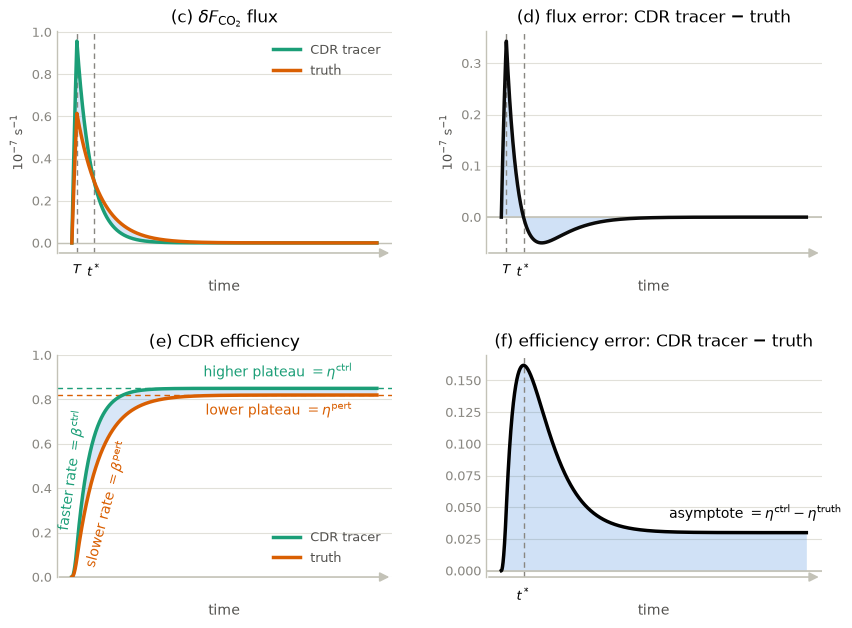

In [3]:
fig = plot_schematic(four_panel=True)

In [5]:
fig.savefig("figures/flux_efficiency_box_model.png", dpi=300, bbox_inches="tight")

---
## Time-varying β(t), η(t), h(t)

The analytic solution requires constant coefficients.  Here we extend to time-varying parameters
by integrating the box-model ODEs numerically (RK45).  We set $S = 1/T$ (unit total intervention,
$S\,T = 1$), so the state variables $A_\mathrm{inv}$ and $D_\mathrm{inv}$ are the alkalinity and
DIC anomalies in those same units:

$$\frac{\mathrm{d}A_\mathrm{inv}}{\mathrm{d}t} = \begin{cases}1/T & t \le T \\ 0 & t > T\end{cases}, \qquad
  \frac{\mathrm{d}D_\mathrm{inv}}{\mathrm{d}t} = \frac{k/\beta(t)}{h(t)}\bigl[\eta(t)\,A_\mathrm{inv} - D_\mathrm{inv}\bigr]$$

$A_\mathrm{inv}$ accumulates to 1 at $t = T$; $D_\mathrm{inv}(t \to \infty) = \eta_\mathrm{eff}$,
so $C(t) = D_\mathrm{inv}(t)$ gives the CDR efficiency directly.

The deployment lasts $T = 30$ days.  The simulation runs for 5 years, during which all
time-varying parameters continue to evolve.

**Conditions maintained at every instant**: $\beta_c(t) < \beta_t(t)$ and $\eta_c(t) > \eta_t(t)$.

---

The four cases use three functional forms, with $t$ in days:

$$h(t) = \bar{h} + h'\cos\!\left(\frac{2\pi t}{365}\right), \qquad \bar{h} = 20\,\mathrm{m},\quad h' = 13\,\mathrm{m}$$

$$\beta_\mathrm{rising}(t;\,\beta_0,r,\tau) = \beta_0\!\left[1 + r\!\left(1 - e^{-t/\tau}\right)\right]$$

$$\beta_\mathrm{osc}(t;\,\beta_0,A,P) = \beta_0 + A\sin\!\left(\frac{2\pi t}{P}\right)$$

$$\eta_\mathrm{drift}(t;\,\eta_0,r,\tau) = \eta_0\!\left[1 + r\!\left(1 - e^{-t/\tau}\right)\right], \quad r < 0$$

| Case | $h(t)$ | $\beta_c(t)$ | $\beta_t(t)$ | $\eta_c(t)$ | $\eta_t(t)$ |
|---|---|---|---|---|---|
| **A** | seasonal | 15 | 22 | 0.85 | 0.80 |
| **B** | 20 m | $\beta_\mathrm{rising}(15,\,0.4,\,400)$ | $\beta_\mathrm{rising}(22,\,0.4,\,400)$ | 0.85 | 0.80 |
| **C** | 20 m | $\beta_\mathrm{osc}(15,\,4,\,180)$ | $\beta_\mathrm{osc}(22,\,4,\,180)$ | $\eta_\mathrm{drift}(0.85,\,-0.06,\,500)$ | $\eta_\mathrm{drift}(0.80,\,-0.06,\,500)$ |
| **D** | seasonal | $\beta_\mathrm{rising}(15,\,0.3,\,400)$ | $\beta_\mathrm{rising}(22,\,0.3,\,400)$ | $\eta_\mathrm{drift}(0.85,\,-0.05,\,600)$ | $\eta_\mathrm{drift}(0.80,\,-0.05,\,600)$ |

In every case $\beta_t - \beta_c = 7$ (constant offset) or $\beta_t/\beta_c = 22/15$ (constant ratio), and $\eta_c - \eta_t = 0.05$ (narrowing slightly as both drift).

In [21]:
from scipy.integrate import solve_ivp

def curves_numeric(beta_c_fn, beta_t_fn, eta_c_fn, eta_t_fn, h_fn,
                   k=4.0e-3, T_days=30.0, years=5.0, n=8001):
    """Box model with time-varying β(t), η(t), h(t), integrated with RK45.

    State: y = [A_inv, D_inv] — normalised inventories (S*T = 1).
    Efficiency: C(t) = D_inv(t),  plateaus at η_eff for constant params.
    Each *_fn: scalar t_days -> value.
    """
    k_m = k / 100.0   # cm/s -> m/s
    T   = T_days * DAY
    S   = 1.0 / T     # normalised: S*T = 1

    def make_rhs(beta_fn, eta_fn):
        def rhs(t, y):
            td  = t / DAY
            h   = h_fn(td)
            a   = k_m / (beta_fn(td) * h)
            src = S if t <= T else 0.0
            return [src, a * (eta_fn(td) * y[0] - y[1])]
        return rhs

    t_eval = np.linspace(0.0, years * 365 * DAY, n)

    def solve_one(beta_fn, eta_fn):
        sol = solve_ivp(make_rhs(beta_fn, eta_fn), (0.0, t_eval[-1]),
                        [0.0, 0.0], t_eval=t_eval, method="RK45",
                        rtol=1e-9, atol=1e-13)
        A, D   = sol.y
        td_a   = sol.t / DAY
        a_arr  = np.array([k_m / (beta_fn(t) * h_fn(t)) for t in td_a])
        eta_a  = np.array([eta_fn(t)                      for t in td_a])
        F      = a_arr * (eta_a * A - D)  # = dD/dt in 1/s
        return F * DAY * 1e3, D           # F in 1e-3/day;  C = D_inv

    F_c, C_c = solve_one(beta_c_fn, eta_c_fn)
    F_t, C_t = solve_one(beta_t_fn, eta_t_fn)
    td = t_eval / DAY

    def _cross(y):
        below = y < -1e-9
        if not below.any() or below[0]:
            return None
        return float(td[np.argmax(below)])

    return dict(t=t_eval, t_days=td,
                F_cdr=F_c, F_truth=F_t,
                C_cdr=C_c, C_truth=C_t,
                err_flux=F_c - F_t, err_eff=C_c - C_t,
                t_star_eff=_cross(C_c - C_t))

In [22]:
# ── parameter-profile factories ───────────────────────────────────────────────
def h_seasonal(h_mean=20, h_amp=13):
    """h(t): deep winter (cos=1 at t=0 ≈ Jan), shallow summer."""
    return lambda td: h_mean + h_amp * np.cos(2 * np.pi * td / 365)

def beta_rising(beta0, r=0.40, tau=400):
    """β growing asymptotically: beta0 * (1 + r*(1 − exp(−t/tau)))."""
    return lambda td: beta0 * (1 + r * (1 - np.exp(-td / tau)))

def beta_osc(beta0, amp=4.0, period=180):
    """β oscillating with sub-annual period."""
    return lambda td: beta0 + amp * np.sin(2 * np.pi * td / period)

def eta_drift(eta0, r=-0.06, tau=500):
    """η decreasing: eta0 * (1 + r*(1 − exp(−t/tau))),  r < 0."""
    return lambda td: eta0 * (1 + r * (1 - np.exp(-td / tau)))

_BC, _BT, _EC, _ET = 15.0, 22.0, 0.85, 0.80  # base control / truth values

# ── four cases ─────────────────────────────────────────────────────────────────
CASES = [
    ("A  seasonal h(t)",
     dict(beta_c_fn=lambda td: _BC,  beta_t_fn=lambda td: _BT,
          eta_c_fn =lambda td: _EC,  eta_t_fn =lambda td: _ET,
          h_fn=h_seasonal(20, 13))),

    ("B  rising β(t)",
     dict(beta_c_fn=beta_rising(_BC, 0.40, 400), beta_t_fn=beta_rising(_BT, 0.40, 400),
          eta_c_fn =lambda td: _EC,               eta_t_fn =lambda td: _ET,
          h_fn=lambda td: 20.0)),

    ("C  oscillating β(t) + drifting η(t)",
     dict(beta_c_fn=beta_osc(_BC, 4, 180),        beta_t_fn=beta_osc(_BT, 4, 180),
          eta_c_fn =eta_drift(_EC, -0.06, 500),    eta_t_fn =eta_drift(_ET, -0.06, 500),
          h_fn=lambda td: 20.0)),

    ("D  all three varying",
     dict(beta_c_fn=beta_rising(_BC, 0.30, 400), beta_t_fn=beta_rising(_BT, 0.30, 400),
          eta_c_fn =eta_drift(_EC, -0.05, 600),   eta_t_fn =eta_drift(_ET, -0.05, 600),
          h_fn=h_seasonal(20, 13))),
]

# verify β_c < β_t and η_c > η_t at a dense time grid
_t_chk = np.linspace(0, 5 * 365, 500)
for lab, kw in CASES:
    bc = np.array([kw['beta_c_fn'](t) for t in _t_chk])
    bt = np.array([kw['beta_t_fn'](t) for t in _t_chk])
    ec = np.array([kw['eta_c_fn'](t)  for t in _t_chk])
    et = np.array([kw['eta_t_fn'](t)  for t in _t_chk])
    print(f"{lab}:  β_t>β_c {(bt>bc).all()}  η_c>η_t {(ec>et).all()}  "
          f"β_c∈[{bc.min():.1f},{bc.max():.1f}]  η_c∈[{ec.min():.3f},{ec.max():.3f}]")

case_labels = [lab for lab, _ in CASES]
case_curves = [curves_numeric(**kw, years=5, n=8001) for _, kw in CASES]

for lab, cv in zip(case_labels, case_curves):
    err = cv['err_eff']
    cross = cv.get('t_star_eff')
    print(f"  {lab}: err_eff ∈ [{err.min():.4f}, {err.max():.4f}]"
          + (f"  crosses at {cross:.0f} d" if cross else "  no crossing"))

A  seasonal h(t):  β_t>β_c True  η_c>η_t True  β_c∈[15.0,15.0]  η_c∈[0.850,0.850]
B  rising β(t):  β_t>β_c True  η_c>η_t True  β_c∈[15.0,20.9]  η_c∈[0.850,0.850]
C  oscillating β(t) + drifting η(t):  β_t>β_c True  η_c>η_t True  β_c∈[11.0,19.0]  η_c∈[0.800,0.850]
D  all three varying:  β_t>β_c True  η_c>η_t True  β_c∈[15.0,19.5]  η_c∈[0.810,0.850]
  A  seasonal h(t): err_eff ∈ [0.0000, 0.1483]  no crossing
  B  rising β(t): err_eff ∈ [0.0000, 0.1481]  no crossing
  C  oscillating β(t) + drifting η(t): err_eff ∈ [0.0000, 0.1501]  no crossing
  D  all three varying: err_eff ∈ [0.0000, 0.1469]  no crossing


In [ ]:
_t_par = np.linspace(0, 5 * 365, 2000)   # same span as simulation

PAR_YLABS = ['h  (m)', r'$\beta$', r'$\eta$']

fig, axs = plt.subplots(3, 4, figsize=(14.0, 6.8), facecolor=SURF)
fig.subplots_adjust(hspace=0.28, wspace=0.16,
                    top=0.87, bottom=0.07, left=0.085, right=0.980)

def _par_ax(ax, bottom_row=False):
    for s in ('top', 'right', 'bottom'): ax.spines[s].set_visible(False)
    ax.spines['left'].set_color(AXIS); ax.spines['left'].set_linewidth(1.2)
    ax.grid(True, axis='y', color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9, length=3)
    ax.set_xticks([])
    if bottom_row:
        _arr = ax.annotate('', xy=(1.0, 0), xytext=(0, 0),
                           xycoords='axes fraction', textcoords='axes fraction',
                           annotation_clip=False,
                           arrowprops=dict(arrowstyle='-|>', color=AXIS,
                                           lw=1.2, mutation_scale=14))
        if _arr.arrow_patch is not None:
            _arr.arrow_patch.set_clip_on(False)
        ax.annotate('time since start of deployment', xy=(0.5, -0.10),
                    xycoords='axes fraction', ha='center', va='top',
                    color=INK2, fontsize=9, annotation_clip=False)

PAR_CAPTIONS = ['h(t)', r'$\beta(t)$', r'$\eta(t)$']

for col, (title, kw) in enumerate(CASES):
    h_arr  = np.array([kw['h_fn'](t)      for t in _t_par])
    bc_arr = np.array([kw['beta_c_fn'](t) for t in _t_par])
    bt_arr = np.array([kw['beta_t_fn'](t) for t in _t_par])
    ec_arr = np.array([kw['eta_c_fn'](t)  for t in _t_par])
    et_arr = np.array([kw['eta_t_fn'](t)  for t in _t_par])

    for row, (yc, yt) in enumerate([(h_arr, None), (bc_arr, bt_arr), (ec_arr, et_arr)]):
        ax = axs[row, col]
        _par_ax(ax, bottom_row=(row == 2))

        letter = chr(ord('a') + row * 4 + col)
        ax.set_title(f'({letter})  {PAR_CAPTIONS[row]}',
                     color=INK, fontsize=10, loc='left', pad=4)

        if yt is None:   # h: same for both runs
            ax.plot(_t_par, yc, color=INK, lw=2)
        else:
            ax.plot(_t_par, yc, color=C_COL, lw=2, label='CDR tracer (control)')
            ax.plot(_t_par, yt, color=T_COL, lw=2, label='truth (perturbed)')
            if col == 0 and row == 1:
                ax.legend(frameon=False, fontsize=9, labelcolor=INK2)

        if col == 0:
            ax.set_ylabel(PAR_YLABS[row], color=INK2, fontsize=9.5)

# column headers
col_titles = [t.split('  ', 1)[1] for t, _ in CASES]
for col, col_title in enumerate(col_titles):
    axs[0, col].annotate(col_title,
                         xy=(0.5, 1.0), xycoords='axes fraction',
                         xytext=(0, 34), textcoords='offset points',
                         ha='center', va='bottom', color=INK, fontsize=10,
                         annotation_clip=False)

fig.suptitle('Parameter profiles: CDR tracer uses control β, η; truth uses perturbed β, η',
             x=0.085, ha='left', color=INK, fontsize=11, fontweight='bold')
plt.show()

In [ ]:
_FLUX_SC = 1e4 / DAY   # stored F (1e-3 day⁻¹) → 10⁻⁷ s⁻¹

ROW_CAPTIONS = [
    r'$\delta F_{\mathrm{CO}_2}$ flux',
    r'flux error: CDR tracer $-$ truth',
    r'CDR efficiency',
    r'efficiency error: CDR tracer $-$ truth',
]
ROW_YLABS = [
    r"$\delta F_{\mathrm{CO}_2}$  ($10^{-7}$ s$^{-1}$)",
    r"flux error  ($10^{-7}$ s$^{-1}$)",
    "efficiency",
    "eff. error",
]

fig, axs = plt.subplots(4, 4, figsize=(14.0, 11.8), facecolor=SURF)
fig.subplots_adjust(hspace=0.26, wspace=0.16,
                    top=0.87, bottom=0.05, left=0.085, right=0.980)

def _ax_num(ax, bottom_row=False):
    for s in ('top', 'right', 'bottom'): ax.spines[s].set_visible(False)
    ax.spines['left'].set_color(AXIS); ax.spines['left'].set_linewidth(1.2)
    ax.grid(True, axis='y', color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9, length=3)
    ax.set_xticks([])
    if bottom_row:
        _arr = ax.annotate('', xy=(1.0, 0), xytext=(0, 0),
                           xycoords='axes fraction', textcoords='axes fraction',
                           annotation_clip=False,
                           arrowprops=dict(arrowstyle='-|>', color=AXIS,
                                           lw=1.2, mutation_scale=14))
        if _arr.arrow_patch is not None:
            _arr.arrow_patch.set_clip_on(False)
        ax.annotate('time since start of deployment', xy=(0.5, -0.10),
                    xycoords='axes fraction', ha='center', va='top',
                    color=INK2, fontsize=9, annotation_clip=False)

for col, (title, cv) in enumerate(zip(case_labels, case_curves)):
    td = cv['t_days']
    F_c  = cv['F_cdr']   * _FLUX_SC
    F_t  = cv['F_truth'] * _FLUX_SC
    fe   = cv['err_flux'] * _FLUX_SC
    C_c, C_t = cv['C_cdr'], cv['C_truth']
    ee   = cv['err_eff']

    for row in range(4):
        ax = axs[row, col]
        _ax_num(ax, bottom_row=(row == 3))

        letter = chr(ord('a') + row * 4 + col)
        ax.set_title(f'({letter})  {ROW_CAPTIONS[row]}',
                     color=INK, fontsize=10, loc='left', pad=4)

        if row == 0:   # ── flux ──────────────────────────────────────────────
            ax.plot(td, F_c, color=C_COL, lw=2.5, zorder=4, label='CDR tracer')
            ax.plot(td, F_t, color=T_COL, lw=2.5, zorder=4, label='truth')
            ax.fill_between(td, F_t, F_c, alpha=0.18, color=CDR, lw=0, zorder=2)
            ax.axhline(0, color=AXIS, lw=1.0, zorder=3)
            if col == 0:
                ax.legend(frameon=False, fontsize=9, labelcolor=INK2)

        elif row == 1: # ── flux error ─────────────────────────────────────────
            ax.fill_between(td, 0, fe, alpha=0.22, color=CDR, lw=0, zorder=2)
            ax.plot(td, fe, color=INK, lw=2.5, zorder=4)
            ax.axhline(0, color=AXIS, lw=1.2, zorder=3)

        elif row == 2: # ── efficiency ─────────────────────────────────────────
            ax.plot(td, C_c, color=C_COL, lw=2.5, zorder=4)
            ax.plot(td, C_t, color=T_COL, lw=2.5, zorder=4)
            ax.fill_between(td, C_t, C_c,
                            where=C_c >= C_t, alpha=0.18, color=CDR, lw=0, zorder=2)
            ax.set_ylim(0, None)

        else:          # ── efficiency error ───────────────────────────────────
            ax.fill_between(td, 0, ee, alpha=0.22, color=CDR, lw=0, zorder=2)
            ax.plot(td, ee, color=INK, lw=2.5, zorder=4)
            ax.axhline(0, color=AXIS, lw=1.2, zorder=3)

        if col == 0:
            ax.set_ylabel(ROW_YLABS[row], color=INK2, fontsize=9.5)

# ── column headers above first row ────────────────────────────────────────────
col_titles = [t.split('  ', 1)[1] for t, _ in CASES]   # strip "A  " prefix
for col, col_title in enumerate(col_titles):
    axs[0, col].annotate(col_title,
                         xy=(0.5, 1.0), xycoords='axes fraction',
                         xytext=(0, 34), textcoords='offset points',
                         ha='center', va='bottom', color=INK, fontsize=10,
                         annotation_clip=False)

fig.suptitle(
    r"Time-varying $\beta(t)$, $\eta(t)$, $h(t)$: "
    r"$C_\mathrm{CDR} \geq C_\mathrm{truth}$ whenever $\beta_c(t) < \beta_t(t)$ "
    r"and $\eta_c(t) > \eta_t(t)$",
    x=0.085, ha='left', color=INK, fontsize=11, fontweight='bold')
plt.show()

---
## Six sensitivity runs

The same six runs across the **delta-FCO2 flux**, its error, the **efficiency**, and its error.
"Delta" throughout means the difference from the counterfactual control run.

**truth** is black solid and **perfect control beta, eta** is black dashed — the two reference
cases.  The four coloured curves each get exactly one sensitivity wrong.

The legend compares the value **prescribed to the CDR tracer** against the **true control-run
value**: "beta > control beta" means the prescribed beta is larger than the control run's actual
beta.  In every case the truth uses the *perturbed* sensitivities — beta larger and eta smaller
than control — because that is what the intervention does to the carbonate system.

Only the reference levels are marked on the y-axes (0 everywhere, 1 on the efficiency panel).
The magnitudes depend on mixing depth, wind and deployment length; the shapes are the point.
Each panel carries its own legend so it can be read independently.

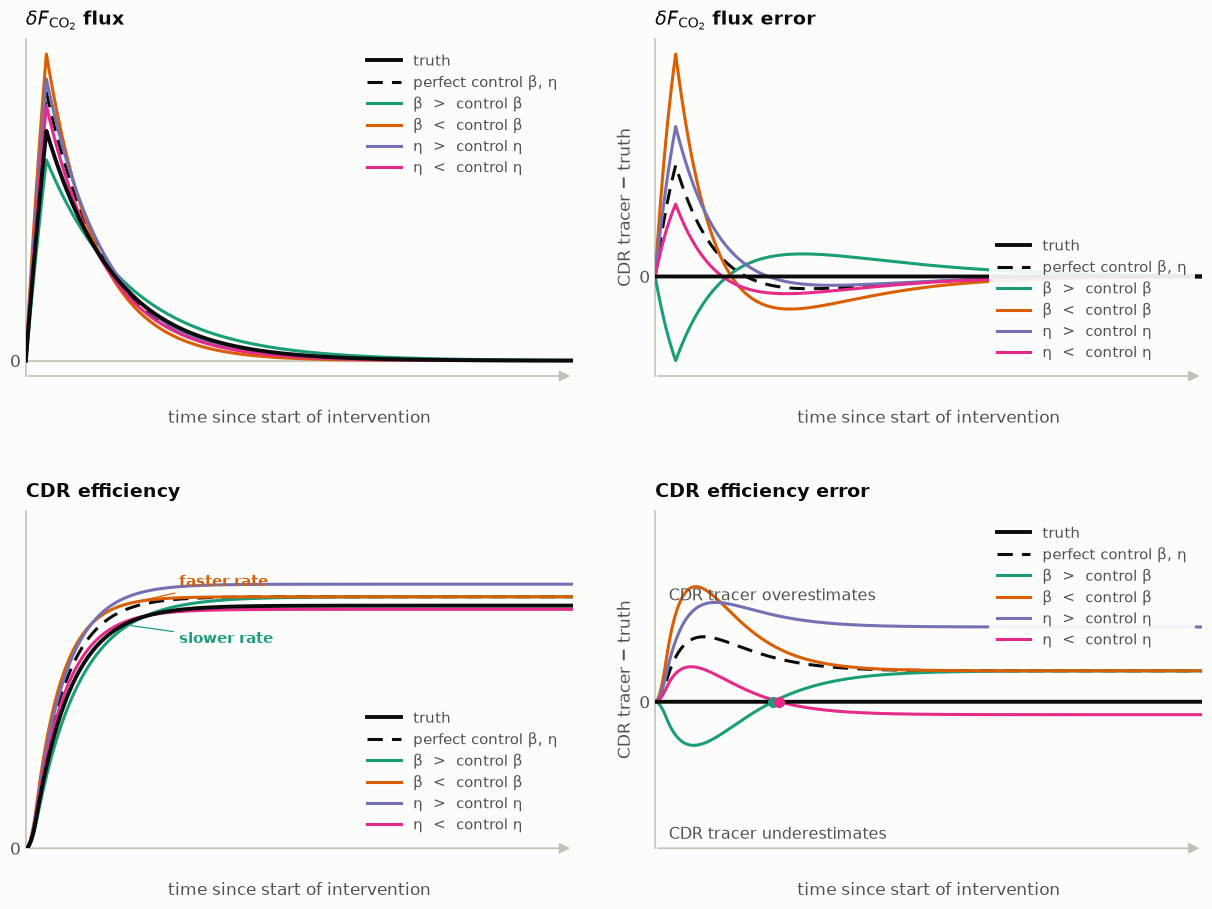

In [19]:
BLK = "#0b0b0b"
BH, BL, EH, EL = "#1b9e77", "#d95f02", "#7570b3", "#e7298a"
BT, ET = 17.25,0.82; BC,EC=15.00,0.85
def cv(b,e): return ct.curves(beta_c=b,beta_t=BT,eta_c=e,eta_t=ET,h_m=20,years=6,n=20001)
S=[("truth",                  None,                 BLK, "-",       2.8),
   ("perfect control β, η",   cv(BC,      EC),      BLK, (0,(5,3)), 2.2),
   ("β  >  control β",        cv(BC*1.40, EC),      BH,  "-",       2.2),
   ("β  <  control β",        cv(BC*0.85, EC),      BL,  "-",       2.2),
   ("η  >  control η",        cv(BC,      EC*1.05), EH,  "-",       2.2),
   ("η  <  control η",        cv(BC,      EC*0.95), EL,  "-",       2.2)]
ref=S[1][1]; td=ref["t_days"]

def style9(ax,title,ylab=None):
    ax.set_facecolor(SURF); ax.grid(True,axis="y",color=GRID,lw=0.8,zorder=0); ax.set_axisbelow(True)
    for s in ("top","right","bottom"): ax.spines[s].set_visible(False)
    ax.spines["left"].set_color(AXIS); ax.spines["left"].set_linewidth(1.2)
    ax.tick_params(colors=INK2,labelsize=12,length=0)
    if ylab: ax.set_ylabel(ylab,color=INK2,fontsize=12)
    ax.set_title(title,color=INK,fontsize=14,loc="left",pad=10,fontweight="bold")
    ax.set_xlim(0,XM); ax.set_xticks([])
    # x-axis as an arrow
    # The arrow tip sits AT the axes edge (x = 1.0), not beyond it. Drawing past the
    # axes (x > 1) gets cropped by the inline backend's tight bbox even with
    # annotation_clip=False, because the artist lands exactly on the boundary.
    _arr = ax.annotate("",xy=(1.0,0),xytext=(0,0),xycoords="axes fraction",
                       textcoords="axes fraction",annotation_clip=False,
                       arrowprops=dict(arrowstyle="-|>",color=AXIS,lw=1.2,mutation_scale=16))
    if _arr.arrow_patch is not None:
        _arr.arrow_patch.set_clip_on(False)
    ax.annotate("time since start of intervention",xy=(0.5,-0.10),xycoords="axes fraction",
                ha="center",va="top",color=INK2,fontsize=12)

def legend(ax,loc):
    hs=[plt.Line2D([],[],color=c,lw=lw,ls=ls,label=lab) for lab,_,c,ls,lw in S]
    lg=ax.legend(handles=hs,loc=loc,fontsize=11,labelcolor=INK2,ncol=1,handlelength=2.2,
                 borderpad=0.5,labelspacing=0.38,frameon=True,framealpha=0.93,edgecolor="none")
    lg.get_frame().set_facecolor(SURF)

fig,axs=plt.subplots(2,2,figsize=(13.0, 9.2),facecolor=SURF)
fig.subplots_adjust(hspace=0.40,wspace=0.15,top=0.955,bottom=0.075,left=0.055,right=0.960)

XM=800
ax=axs[0,0]; style9(ax,r"$\delta F_{\text{CO}_2}$ flux")
ax.axhline(0,color=AXIS,lw=1.2,zorder=1)
for lab,c,col,ls,lw in S:
    ax.plot(td, ref["F_truth"] if c is None else c["F_cdr"],color=col,lw=lw,ls=ls,
            zorder=5 if c is None else 3)
ax.set_yticks([0]); ax.set_yticklabels(["0"]); legend(ax,"upper right")

ax=axs[0,1]; style9(ax,r"$\delta F_{\text{CO}_2}$ flux error","CDR tracer − truth")
for lab,c,col,ls,lw in S:
    ax.plot(td, np.zeros_like(td) if c is None else c["err_flux"],color=col,lw=lw,ls=ls,
            zorder=5 if c is None else 3)
ax.set_yticks([0]); ax.set_yticklabels(["0"]); legend(ax,"lower right")

XM=1500
ax=axs[1,0]; style9(ax,"CDR efficiency")
#ax.axhline(0.9,color=MUTED,lw=1.1,ls=(0,(4,3)),zorder=1)
for lab,c,col,ls,lw in S:
    ax.plot(td, ref["C_truth"] if c is None else c["C_cdr"],color=col,lw=lw,ls=ls,
            zorder=5 if c is None else 3)
ax.set_ylim(0,1.14); ax.set_yticks([0]); ax.set_yticklabels(["0"])
legend(ax,"lower right")
#ax.annotate("plateau = prescribed η",xy=(40,1.055),color=INK2,fontsize=11.5)
# Rate labels for the two beta curves
_i_ann = np.searchsorted(td, 280)
_bh_v = S[2][1]["C_cdr"][_i_ann]   # beta > control (slower)
_bl_v = S[3][1]["C_cdr"][_i_ann]   # beta < control (faster)
ax.annotate("slower rate", xy=(td[_i_ann], _bh_v), xytext=(420, _bh_v - 0.06),
            color=BH, fontsize=11, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=BH, lw=0.9))
ax.annotate("faster rate", xy=(td[_i_ann], _bl_v), xytext=(420, _bl_v + 0.06),
            color=BL, fontsize=11, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=BL, lw=0.9))

ax=axs[1,1]; style9(ax,"CDR efficiency error","CDR tracer − truth")
for lab,c,col,ls,lw in S:
    y=np.zeros_like(td) if c is None else c["err_eff"]
    ax.plot(td,y,color=col,lw=lw,ls=ls,zorder=5 if c is None else 3)
    if c is not None:
        k=np.where(np.diff(np.sign(y[20:])))[0]
        if len(k): ax.plot([td[20+k[0]]],[0],"o",ms=7,color=col,zorder=6)
ax.set_ylim(-0.185,0.142); ax.set_yticks([0]); ax.set_yticklabels(["0"])
legend(ax,"upper right")
ax.text(0.025,0.735,"CDR tracer overestimates",transform=ax.transAxes,color=INK2,fontsize=11.5)
ax.text(0.025,0.028,"CDR tracer underestimates", transform=ax.transAxes,color=INK2,fontsize=11.5)
plt.show()


fig.savefig(
    "figures/efficiency_crossover.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=1
)

### What each panel shows

**delta-FCO2 flux** - every run has the same shape: rise while the intervention runs, then relax.
The prescribed beta sets the decay rate, so those runs relax visibly faster or slower than the
truth. The eta runs share the truth's rate and differ only in amplitude.

**delta-FCO2 flux error** - all the structure is early and has decayed to nothing well before the
end. Good for seeing the rate error, useless at long lead times because the flux itself has gone
to zero. This is why the efficiency error is the better diagnostic.

**Efficiency** - the plateau is the prescribed eta; the approach rate is set by the prescribed
beta. Both beta runs and the perfect run converge to one level; the eta runs converge to different
levels. The dashed line at 1 is full efficiency - one mole taken up per mole intervened.

**Efficiency error** - the discriminator. Three things to read off:

- the **early sign** is a pure beta diagnostic - positive when the CDR tracer relaxes faster than
  the truth, negative when it relaxes slower;
- the **asymptote** is a pure eta diagnostic, equal to prescribed eta minus true eta, with no beta
  contamination - which is why both beta runs land on the same final level as the perfect run;
- a **crossing** happens only when those two disagree in sign.

Two runs cross zero, and in **opposite directions**: beta above control goes negative to positive,
eta below control goes positive to negative. Only the second matches the observed behaviour.

That the two crossings fall at a similar time here is an accident of these parameters - the timing
is set by h*beta/k in both cases. The *direction* carries the information.

*Colour note: the four hues are ColorBrewer Dark2 (1b9e77, d95f02, 7570b3, e7298a). The palette
validator could not be run on this machine (no node), so this rests on that palette's own
colourblind-safe design rather than a measured check against this surface.*